In [9]:
import scanpy as sc
import anndata as ad
import numpy as np

In [10]:
input_dir = "/Users/apple/Desktop/KB/data"
adata = ad.read_h5ad(input_dir+'/BiddyData/Biddy_train.h5ad')
# adata_test = ad.read_h5ad(input_dir+'/BiddyData/Biddy_test.h5ad')

train_labels = adata.obs["clone_id"].to_numpy()
# test_labels = adata_test.obs["clone_id"].to_numpy()

embed_dir = input_dir + "/feat_LCL_2025/cell_tag/feat_celltag_lambda005_unlab5_bs50_testAsPenalty"
train_embeddings = np.load(embed_dir+'/train_proj_embed.npy')
# test_embeddings = np.load(embed_dir+'/test_proj_embed.npy')


print(train_labels.shape)
print(train_embeddings.shape)

(5893,)
(5893, 32)


In [11]:
adata.obsm["X_emb"] = train_embeddings
sc.pp.neighbors(adata, use_rep="X_emb")
# 2. Run UMAP
sc.tl.umap(adata, random_state=42)
resolution = 0.05
# 3. Leiden clustering (choose resolution)
sc.tl.leiden(adata, resolution=resolution)

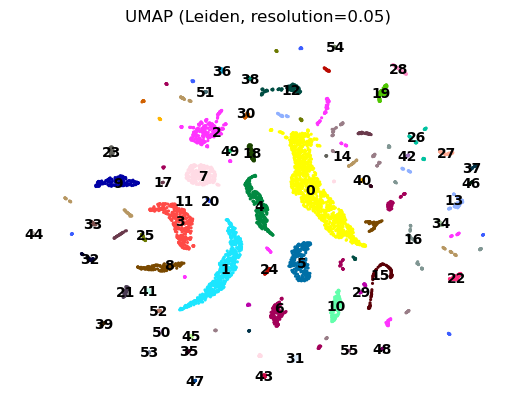

In [12]:
sc.pl.umap(
    adata,
    color="leiden",
    title=f"UMAP (Leiden, resolution={resolution})",
    size=20,
    legend_loc="on data",   # or "right margin"
    frameon=False
)

In [13]:
len(adata.obs["leiden"].unique()), len(adata.obs["clone_id"].unique())

(56, 169)

In [14]:
cluster_lineage_counts = {}

for cluster in adata.obs["leiden"].unique():
    cells = adata.obs[adata.obs["leiden"] == cluster]
    n_lineages = cells["clone_id"].nunique()
    cluster_lineage_counts[cluster] = n_lineages

In [15]:
values = list(cluster_lineage_counts.values())

print("Average lineages per cluster:", np.mean(values))
print("Median:", np.median(values))
print("Max:", np.max(values))

Average lineages per cluster: 3.0714285714285716
Median: 1.0
Max: 27


In [16]:
print("Clusters with >1 lineage:", np.mean(np.array(values) > 1))

Clusters with >1 lineage: 0.4107142857142857
